## PCA 
# from sklearn.decomposition import PCA
把 100 個特徵壓縮成更少的特徵
但盡量保留原本資料的資訊
例如：100個特徵 → 10個主成分
這 10 個主成分涵蓋了原本 90% 的資訊

特徵太多 → 模型訓練慢
特徵太多 → 過擬合風險高
特徵太多 → 很難視覺化

PCA 降維後：
→ 訓練更快
→ 比較不容易過擬合
→ 可以畫圖看資料分佈

# 壓縮方式
變異數大 = 這個方向資料變化多 = 資訊多
變異數小 = 這個方向資料變化少 = 資訊少


# X.shape[1]
特徵數（columns）有幾個
# X.shape[0]
樣本數（rows）有幾個

# 標準化	StandardScaler	平均=0、標準差=1
# 正規化	MinMaxScaler	壓到 0~1

# 建立 PCA 模型，保留 2 個主成分
pca = PCA(n_components=2)

# 學習資料的主要變化方向，並將資料投影到 2 維空間
X_pca = pca.fit_transform(X_scaled)

# print(f"保留了多少資訊: {pca.explained_variance_ratio_.sum():.2%}")

.explained_variance_ratio_ 保留了原始資料多少資訊（變異量）保真率

.sum()所有column相加

:.2% 轉成百分比 保留 2 位小數

# 優點：
  → 降低維度，加快訓練
  → 去除特徵間的相關性
  → 可以視覺化高維資料

# 缺點：
  → 主成分不好解釋（不是原本的特徵）
  → 一定要先標準化
  → 可能丟失一些資訊

# 適合場景：
  → 特徵很多（100個以上）
  → 想視覺化資料分佈
  → 特徵之間高度相關

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs

plt.rcParams['font.family'] = 'Microsoft JhengHei'
plt.rcParams['axes.unicode_minus'] = False

X,y=make_blobs(
    n_samples=500,
    centers=3,
    n_features=10,
    random_state=42
)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"原始維度: {X.shape[1]}")
print(f"降維後: {X_pca.shape[1]}")
print(f"保留了多少資訊: {pca.explained_variance_ratio_.sum():.2%}")

原始維度: 10
降維後: 2
保留了多少資訊: 92.65%


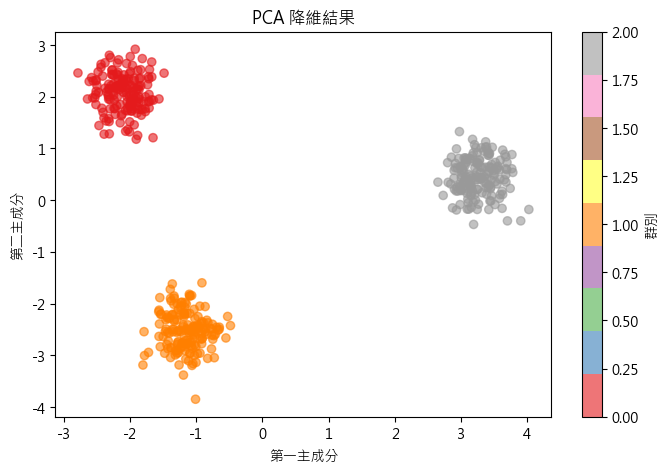

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='Set1', alpha=0.6)
plt.xlabel('第一主成分')
plt.ylabel('第二主成分')
plt.title('PCA 降維結果')
plt.colorbar(label='群別')
plt.show()

# plt.bar 長條圖
# plt.plot 折線圖

# .cumsum() 累加

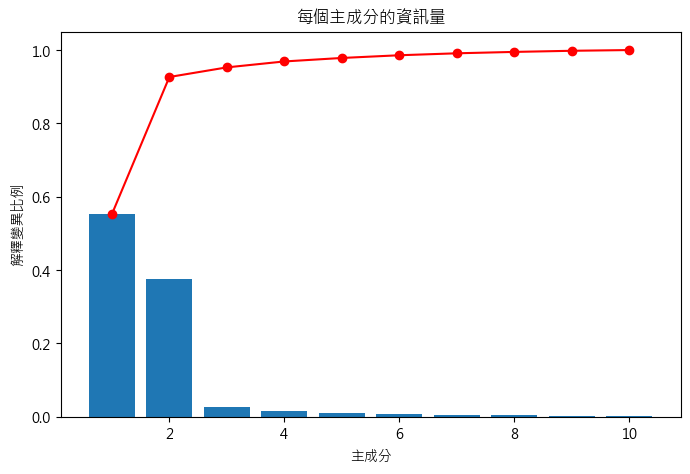

In [10]:
pca_full = PCA()
pca_full.fit(X_scaled)

plt.figure(figsize=(8, 5))
plt.bar(range(1, 11), pca_full.explained_variance_ratio_)
plt.plot(range(1, 11), 
         pca_full.explained_variance_ratio_.cumsum(), 
         marker='o', color='red', label='累積')
plt.xlabel('主成分')
plt.ylabel('解釋變異比例')
plt.title('每個主成分的資訊量')

plt.show()